<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-01/intro_and_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 01 — Introduction to AI and the Data-Science Workflow

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
By the end of this lecture you will be able to:
1. Describe what **Artificial Intelligence** and **Machine Learning** are, and how
   they relate to data.
2. Walk through the **data-science workflow**: *question → data → explore → model
   → evaluate → communicate*.
3. Load a **real-world climate dataset**, inspect it, and produce a first
   exploratory analysis with `pandas` and `matplotlib`.

## The dataset
We use **NASA GISTEMP v4** — the global land–ocean surface temperature *anomaly*
(°C relative to the 1951–1980 average), one value per year from 1880 to today.
See the [dataset card](../../datasets/gistemp_global_annual.DATASET.md).

> **Why climate data?** It is openly licensed, easy to understand, and connects
> AI methods to a real scientific question: *how is the planet's temperature
> changing, and can we model it?*

### 1. Set up and load the data

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


Matplotlib is building the font cache; this may take a moment.


In [2]:
temp = load_dataset("gistemp_global_annual.csv")
print("shape:", temp.shape)
temp.head()

shape: (146, 2)


,year,temp_anomaly_c
0,1880,-0.18
1,1881,-0.09
2,1882,-0.11
3,1883,-0.18
4,1884,-0.29


### 2. Inspect the data

Every analysis starts by *looking* at the data: its size, columns, types, and
basic statistics. This is how we catch problems (missing values, wrong units)
before modeling.

In [3]:
temp.info()
temp.describe()

<class 'pandas.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   year            146 non-null    int64  
 1   temp_anomaly_c  146 non-null    float64
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


,year,temp_anomaly_c
count,146.000000,146.000000
mean,1952.500000,0.082123
std,42.290661,0.401860
min,1880.000000,-0.490000
25%,1916.250000,-0.200000
50%,1952.500000,-0.030000
75%,1988.750000,0.317500
max,2025.000000,1.280000


### 3. Explore — plot the time series

A picture is the fastest way to understand a temporal dataset.

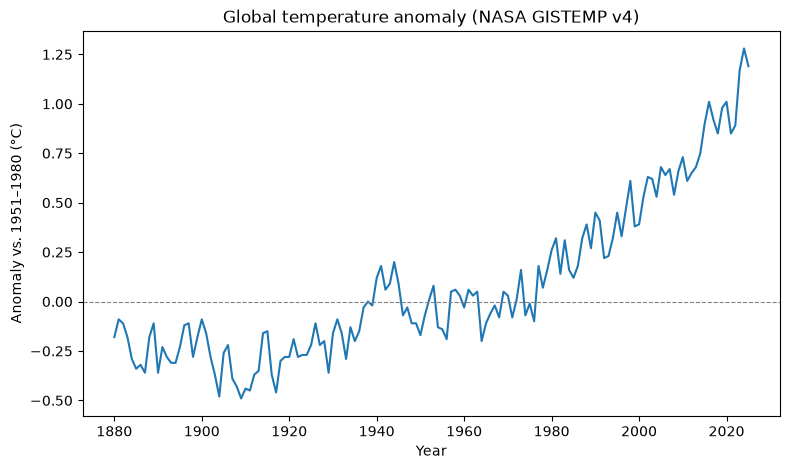

In [4]:
ax = temp.plot(x="year", y="temp_anomaly_c", legend=False)
ax.set_title("Global temperature anomaly (NASA GISTEMP v4)")
ax.set_xlabel("Year")
ax.set_ylabel("Anomaly vs. 1951–1980 (°C)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.show()

### 4. Smooth the signal

Year-to-year values are noisy. A **rolling mean** (here, 10 years) reveals the
underlying trend — a first taste of *feature engineering*.

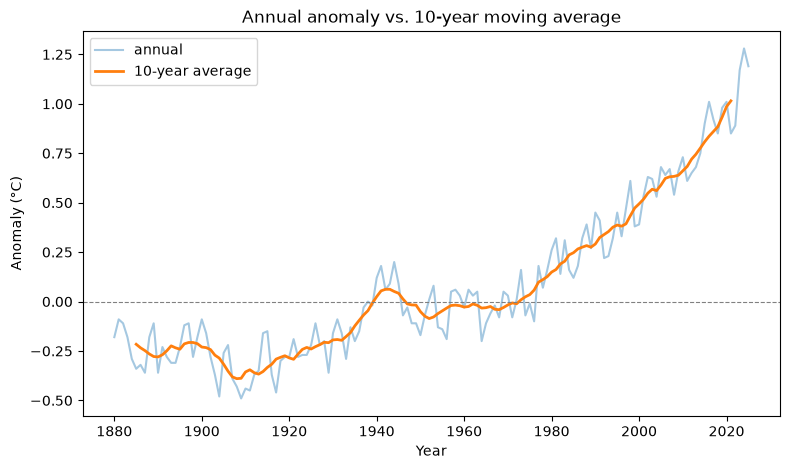

In [5]:
temp["rolling_10y"] = temp["temp_anomaly_c"].rolling(window=10, center=True).mean()

ax = temp.plot(x="year", y="temp_anomaly_c", label="annual", alpha=0.4)
temp.plot(x="year", y="rolling_10y", ax=ax, label="10-year average", linewidth=2)
ax.set_title("Annual anomaly vs. 10-year moving average")
ax.set_xlabel("Year"); ax.set_ylabel("Anomaly (°C)")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
plt.show()

### 5. Summarize by decade

Grouping is one of the most common data operations. Let's average by decade.

In [6]:
temp["decade"] = (temp["year"] // 10) * 10
by_decade = temp.groupby("decade")["temp_anomaly_c"].mean().round(3)
by_decade.tail(8)

decade
1950   -0.047
1960   -0.031
1970    0.035
1980    0.247
1990    0.387
2000    0.589
2010    0.808
2020    1.065
Name: temp_anomaly_c, dtype: float64

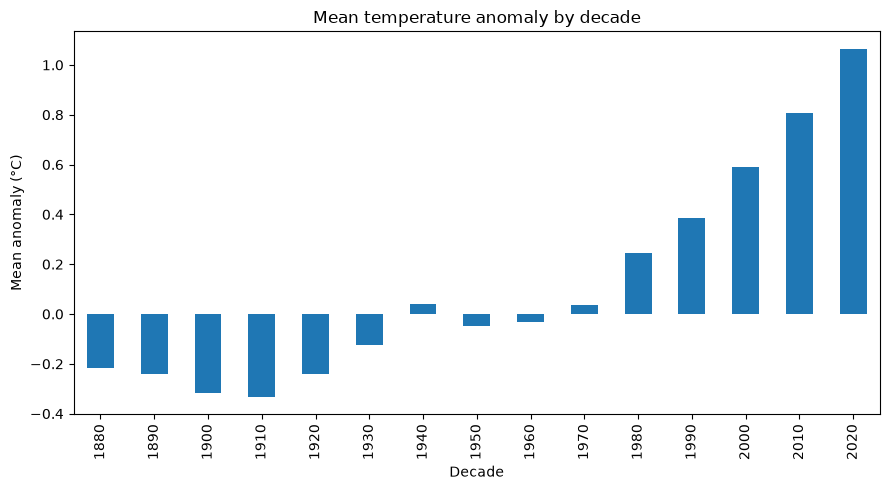

In [7]:
ax = by_decade.plot(kind="bar")
ax.set_title("Mean temperature anomaly by decade")
ax.set_xlabel("Decade"); ax.set_ylabel("Mean anomaly (°C)")
plt.tight_layout(); plt.show()

### 6. What did we learn?

- The global anomaly has risen from roughly **−0.2 °C** in the late 1800s to well
  over **+1.0 °C** in recent years.
- The warming is not just noise: the 10-year average climbs steadily, especially
  after ~1970.
- We did all of this with the core toolkit you'll use all course long:
  `load → inspect → visualize → transform → summarize`.

This *exploratory data analysis* (EDA) is step zero of every machine-learning
project. In the next lectures we move from *describing* the data to *modeling*
and *predicting* it.

### Exercises
1. Change the rolling window from 10 to 5 and to 30 years. How does the trend
   line change? Which window best balances *smoothness* vs. *detail*?
2. Compute the average anomaly for the most recent 30 years vs. the first 30
   years of the record. What is the difference, in °C?
3. The dataset card lists a `D-N` (December–November) annual column upstream.
   Read the raw NASA file and compare it to the `J-D` column we used.
4. **Discuss:** EDA *describes* what happened. What extra ingredient does a
   *model* add that EDA alone cannot give you?